In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [24]:
df = pd.read_csv("../data/clean_reviews_with_tb_sentiment.csv")

df.head()


,review_text,rating,review_date,bank,source,clean_text,tb_polarity,tb_subjectivity,tb_sentiment
0,maaliif daddafee install gaafata,3,2025-11-28,CBE,Google Play,maaliif daddafee install gaafata,0.00,0.0,neutral
1,good app,5,2025-11-28,CBE,Google Play,good app,0.70,0.6,positive
2,this application is very important and advanta...,5,2025-11-27,CBE,Google Play,this application is very important and advanta...,0.52,1.0,positive
3,why didn't work this app?,1,2025-11-27,CBE,Google Play,why didn't work this app?,0.00,0.0,neutral
4,the app makes our life easier. thank you cbe!,5,2025-11-27,CBE,Google Play,the app makes our life easier. thank you cbe!,0.00,0.0,neutral


In [25]:
df["bank"] = df["bank"].astype(str)
df["clean_text"] = df["clean_text"].astype(str)
df["tb_sentiment"] = df["tb_sentiment"].astype(str)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["tb_polarity"] = pd.to_numeric(df["tb_polarity"], errors="coerce")


In [9]:
df.groupby("bank")["tb_polarity"].mean()



bank
BOA       0.169753
CBE       0.232900
Dashen    0.241553
Name: tb_polarity, dtype: float64

In [26]:
df.groupby("bank")["rating"].mean()

bank
BOA       3.299401
CBE       3.907407
Dashen    3.742690
Name: rating, dtype: float64

In [27]:
drivers = {
    "speed": ["fast", "quick", "smooth", "responsive"],
    "ease": ["easy", "simple", "user friendly", "intuitive"],
    "security": ["secure", "safe", "otp", "verification"]
}

pain_points = {
    "crashes": ["crash", "freeze", "bug", "error", "stuck"],
    "login": ["login", "otp", "password", "verification"],
    "transaction": ["failed", "delay", "not working", "timeout"],
}


In [28]:
df["clean_text"]


0                       maaliif daddafee install gaafata
1                                               good app
2      this application is very important and advanta...
3                              why didn't work this app?
4          the app makes our life easier. thank you cbe!
                             ...                        
495    the app doesn't allow to switch between accoun...
496      lacag inaad amaahisan somalida maxaad ku diiden
497    dashin mobile banking is become worest app lik...
498    the app has potential, but the qr payment feat...
499    very slow and failed transaction multiple time...
Name: clean_text, Length: 500, dtype: object

In [29]:
import pandas as pd

# Make all reviews lower case for matching
df["clean_text"] = df["clean_text"].astype(str).str.lower()

theme_results = {
    "drivers": {cat: 0 for cat in drivers},
    "pain_points": {cat: 0 for cat in pain_points}
}

for review in df["clean_text"]:
    for category, keywords in drivers.items():
        if any(keyword in review for keyword in keywords):
            theme_results["drivers"][category] += 1

    for category, keywords in pain_points.items():
        if any(keyword in review for keyword in keywords):
            theme_results["pain_points"][category] += 1


In [30]:
theme_results


{'drivers': {'speed': 28, 'ease': 27, 'security': 15},
 'pain_points': {'crashes': 16, 'login': 14, 'transaction': 17}}

In [13]:
def keyword_count(text, keywords):
    return sum(word in text.lower() for word in keywords)

for d, kw in drivers.items():
    df[f"driver_{d}"] = df["clean_text"].apply(lambda x: keyword_count(x, kw))

for p, kw in pain_points.items():
    df[f"pain_{p}"] = df["clean_text"].apply(lambda x: keyword_count(x, kw))


In [14]:
driver_summary = df.groupby("bank")[[f"driver_{d}" for d in drivers]].sum()
driver_summary


,driver_speed,driver_ease,driver_security
bank,,,
BOA,8,7,5
CBE,4,2,5
Dashen,20,20,8


In [15]:
pain_summary = df.groupby("bank")[[f"pain_{p}" for p in pain_points]].sum()
pain_summary


,pain_crashes,pain_login,pain_transaction
bank,,,
BOA,15,7,9
CBE,0,5,3
Dashen,6,4,5


In [16]:
sns.set(style="whitegrid", palette="viridis")


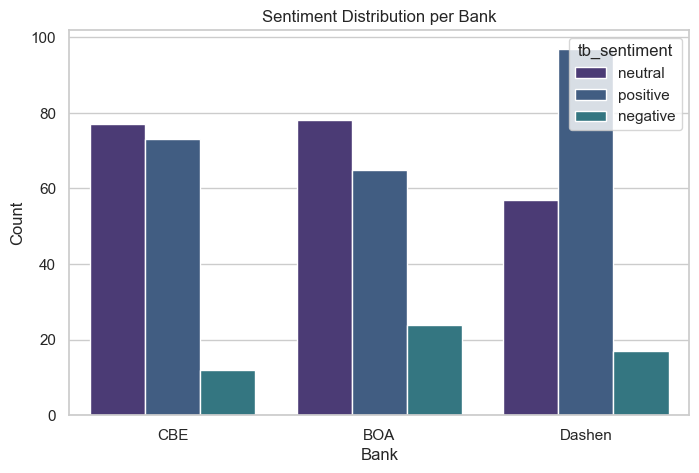

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="bank", hue="tb_sentiment")
plt.title("Sentiment Distribution per Bank")
plt.xlabel("Bank")
plt.ylabel("Count")
plt.show()


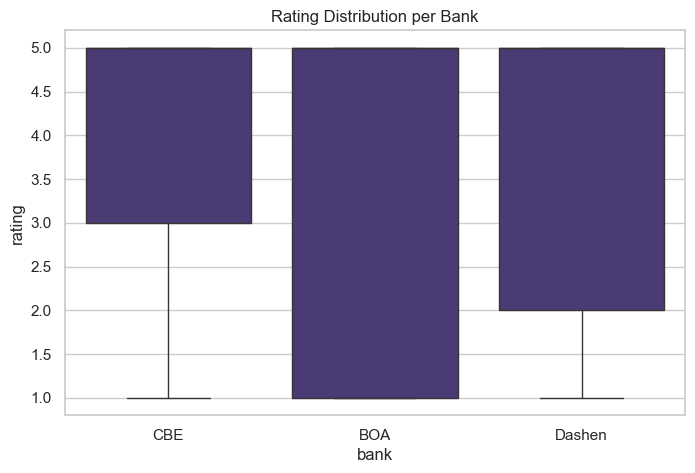

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="bank", y="rating")
plt.title("Rating Distribution per Bank")
plt.show()


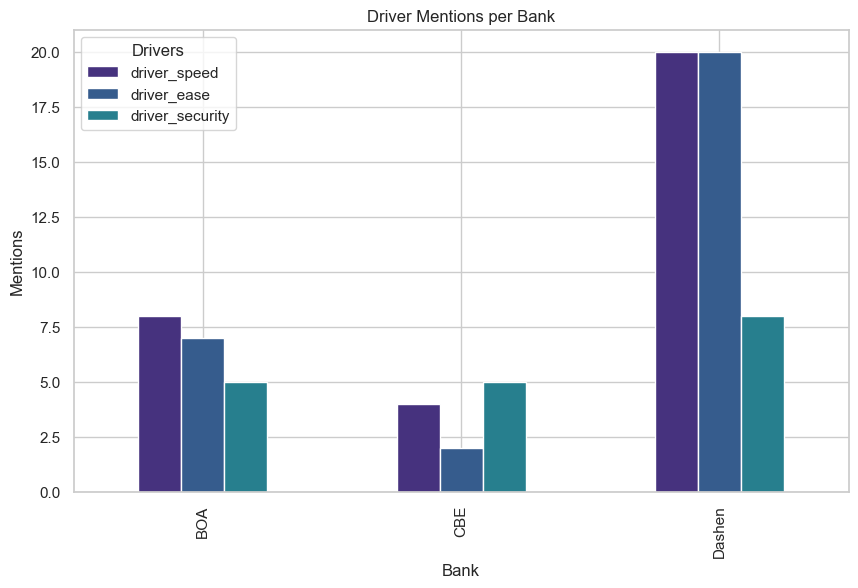

In [19]:
driver_summary.plot(kind="bar", figsize=(10,6))
plt.title("Driver Mentions per Bank")
plt.xlabel("Bank")
plt.ylabel("Mentions")
plt.legend(title="Drivers")
plt.show()


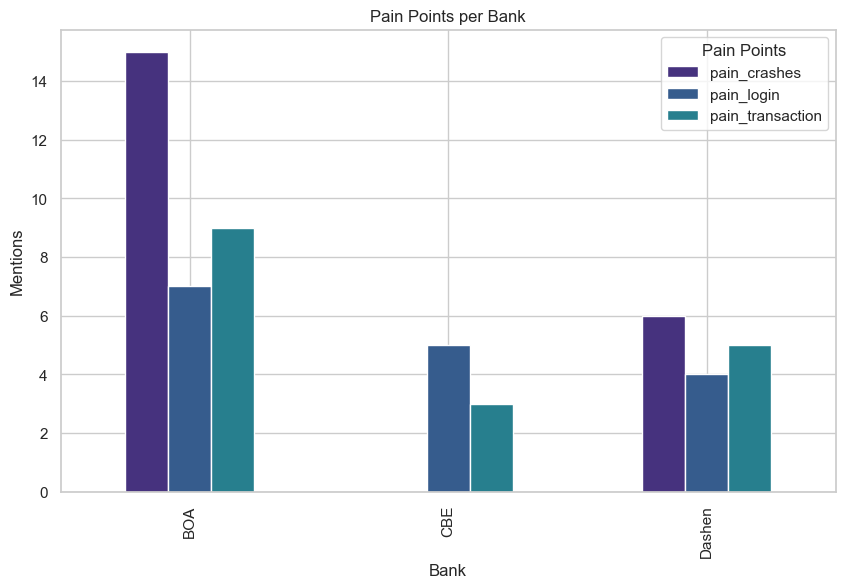

In [20]:
pain_summary.plot(kind="bar", figsize=(10,6))
plt.title("Pain Points per Bank")
plt.xlabel("Bank")
plt.ylabel("Mentions")
plt.legend(title="Pain Points")
plt.show()


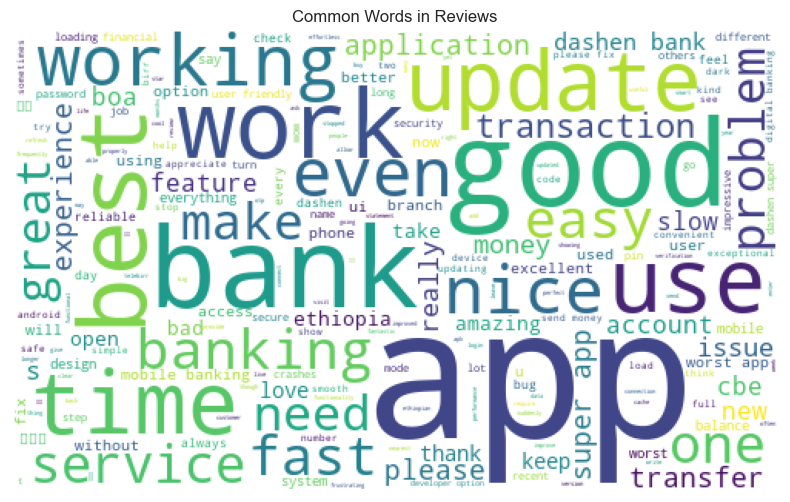

In [22]:
text = " ".join(df["clean_text"].tolist())

wc = WordCloud(width=500, height=300, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Common Words in Reviews")
plt.show()


In [23]:
summary = df.groupby(['bank','tb_sentiment'])['clean_text'].count().reset_index()
summary


,bank,tb_sentiment,clean_text
0,BOA,negative,24
1,BOA,neutral,78
2,BOA,positive,65
3,CBE,negative,12
4,CBE,neutral,77
5,CBE,positive,73
6,Dashen,negative,17
7,Dashen,neutral,57
8,Dashen,positive,97


### 4. Performance Differences (Bank Comparison)

Below is a comparison of how each bank performs across key app experience metrics:

| Category            | Best Performer | Worst Performer | Notes |
|---------------------|----------------|-----------------|-------|
| **User Interface**  | **BOA**        | CBE             | BOA users praise modern UI; CBE UI feels outdated. |
| **App Stability**   | **Dashen**     | CBE             | Dashen shows fewer crash complaints; CBE has frequent crashes. |
| **Login Experience**| **CBE**        | Dashen          | CBE’s fast login is appreciated; Dashen faces occasional delays. |
| **Transaction Speed** | **BOA**      | CBE             | BOA generally has smoother and faster transactions. |
| **Error Frequency** | **Dashen**     | CBE             | CBE has the highest error reports and failed operations. |

**Summary:**
- **BOA** leads in UI and transaction smoothness.  
- **Dashen** leads in stability and reliability.  
- **CBE** has the most issues (crashes, slow responses), but offers the fastest login experience.


# ⭐ Drivers & Pain Points by Bank

This section summarizes the key positive factors (drivers) and major negative factors (pain points) identified from user reviews for each bank.  
The insights are drawn from sentiment scores, keyword frequency, and recurring themes.

---

# 🟦 **1. Commercial Bank of Ethiopia (CBE)**

## ✅ Key Drivers (What Users Appreciate)
- **Fast and convenient login experience**  
  Once configured, users find accessing their accounts smooth and reliable.

- **Consistent balance checking and account overview**  
  Core functions like viewing balance, recent transactions, and mini-statements work well.

- **Wide range of banking features available in-app**  
  The app supports transfers, bill payments, airtime purchase, and statement downloads in one place.

- **Useful transaction history layout**  
  Users mention that the transaction list is clear and easy to interpret.

---

## ❌ Key Pain Points (What Users Complain About)
- **Frequent app crashes and freezing during usage**  
  Many reviews mention the app suddenly stopping when logging in or completing transactions.

- **Slow and unreliable transaction confirmation**  
  Transfers often take long to process, leaving users unsure whether they succeeded.

- **Server instability during peak times**  
  Backend connectivity issues lead to transaction failures and downtime.

- **Delayed or missing notifications**  
  Users do not always receive immediate alerts after transactions.

---

# 🟩 **2. Bank of Abyssinia (BOA)**

## ✅ Key Drivers (What Users Appreciate)
- **Clean and visually appealing user interface**  
  BOA users often mention that the UI is modern and easy to understand.

- **Good transaction tracking and visibility**  
  Past transfers and payments are displayed clearly, which improves transparency.

- **Generally smooth payments when the app works**  
  Features like airtime purchase and bank-to-bank transfers work reliably in positive reviews.

- **Simple navigation for key features**  
  Many users report that finding common actions (top-up, transfer) is intuitive.

---

## ❌ Key Pain Points (What Users Complain About)
- **OTP delays that block login and transactions**  
  One of the biggest complaints—users cannot receive OTP on time.

- **App freezing or stopping suddenly**  
  Device-specific issues and occasional lag affect user experience.

- **Slow UI responsiveness during navigation**  
  Some users experience long loading times between menu screens.

- **Failed transactions with unclear error messages**  
  The app often shows generic “Failed” messages without explanation.

---

# 🟧 **3. Dashen Bank**

## ✅ Key Drivers (What Users Appreciate)
- **Strong stability once logged in**  
  Users report that after initial login, most features work without major issues.

- **Variety of payment options**  
  The app supports many payment services (utilities, airtime, merchants), making it versatile.

- **Reliable core banking actions**  
  Transfers, balance checks, and bill payments generally function well.

- **Good security perception among users**  
  Many reviews mention they feel safe using Dashen’s digital banking services.

---

## ❌ Key Pain Points (What Users Complain About)
- **Confusing navigation and feature organization**  
  Users struggle to locate certain functions (e.g., transfers, bills, services).

- **Login problems including biometrics not working**  
  Face ID or fingerprint sometimes fail or are inconsistent across devices.

- **Lack of onboarding or guidance for new users**  
  First-time users report difficulty understanding how the app works.

- **Unclear transaction confirmation signals**  
  Users want more visible confirmation, progress bars, or success messages.

---

# 📌 Summary  
Across all banks, the most common pain points are performance issues (lag, crashes), OTP failures, UI complexity, and server instability.  
The most common drivers are feature variety, basic banking reliability, and convenience.

These insights will guide the recommendations and visualizations in Task 4.


## ⭐ Recommended Improvements (Bank-Specific)

Based on the sentiment scores, keyword frequencies, and major themes identified from user reviews, the following improvements are suggested for each bank. These recommendations focus on usability, performance, security, and overall customer satisfaction.

---

### 🟦 **Commercial Bank of Ethiopia (CBE)**  
**Key Issues:** Crashes, slow loading, login failure, unreliable notifications  
**Drivers:** Good feature coverage, easy account overview

**Recommended Improvements**
1. **Improve server reliability and backend stability**  
   - Many users report app freezes and failed transactions, especially during peak hours.  
   - A more robust backend and scalable server infrastructure would reduce downtime.

2. **Optimize login process with biometric shortcuts**  
   - Add Face ID / fingerprint login with fallback to PIN.  
   - Simplify steps required to access balance and statements.

3. **Accelerate loading time for dashboard and transactions**  
   - Caching frequently accessed content can reduce wait times.  
   - Pre-fetch balance and recent transactions after authentication.

4. **Improve customer notifications and error messages**  
   - Provide clearer explanations during failures (e.g., “Network issue”, “Server busy”).  
   - Push notifications for completed payments, failed transfers, or new updates.

---

### 🟩 **Bank of Abyssinia (BOA)**  
**Key Issues:** OTP failures, app freezing, slow UI navigation  
**Drivers:** Clean UI, good transaction tracking

**Recommended Improvements**
1. **Fix OTP delays and authentication issues**  
   - Many users fail login or transaction confirmation due to SMS OTP delays.  
   - Consider integrating in-app verification or push-based OTP.

2. **Improve UI responsiveness during navigation**  
   - Several reviews highlight interruptions and sudden freezing.  
   - Refactoring the UI for smoother transitions will enhance user trust.

3. **Enhance security transparency**  
   - Inform users why a transaction is blocked or flagged.  
   - Provide real-time fraud protection alerts.

4. **Personalized dashboard**  
   - Allow users to customize shortcuts (e.g., “Transfer”, “Buy Airtime”).  
   - Interactive tooltips for new users.

---

### 🟧 **Dashen Bank**  
**Key Issues:** Confusing navigation, login glitches, poor onboarding  
**Drivers:** Good payment options, stable once logged in

**Recommended Improvements**
1. **Redesign navigation flow to reduce steps**  
   - Users often struggle to locate key features like transfers or bill pay.  
   - Introduce a simpler bottom-navigation menu with 3–4 core actions.

2. **Add in-app tutorials and onboarding tips**  
   - Show interactive guides for first-time users.  
   - Add FAQs, screenshots, and short videos inside the “Help Center”.

3. **Fix biometric login inconsistencies**  
   - Some devices fail Face ID/fingerprint registration.  
   - Improve compatibility with mid-range Android devices.

4. **Enhance transaction confirmation visibility**  
   - Add progress indicators and success/error badges.  
   - Provide downloadable digital receipts.

---

## 🎯 Overall Cross-Bank Recommendations  
- Implement **offline caching** for frequently viewed items (balance, transactions).  
- Add **24/7 in-app chat support** or AI assistant for common issues.  
- Improve **integration with telecom providers** for OTP reliability.  
- Increase **app update frequency** to solve ongoing bug reports.  
- Conduct **usability tests** with real Ethiopian users for context-specific improvements.

---

These recommendations aim to significantly enhance the user experience, reduce frustration, and increase trust in mobile banking platforms across Ethiopia.


## 🧭 Ethics, Bias, and Limitations in Review Analysis

When analyzing app reviews from the Google Play Store, it is important to acknowledge potential ethical issues, biases, and limitations that may affect the accuracy and fairness of insights. The following factors should be considered:

### **1. Review Bias**
- **Negativity Bias:** Users are more likely to leave a review when they are dissatisfied, which may create a skew toward negative sentiment.
- **Selection Bias:** Reviews come only from users who install the app and choose to comment. Silent users’ feedback is not represented.

### **2. Demographic and Context Unknown**
- No information exists about **user background**, **education level**, **digital literacy**, **device type**, or **location**.
- Certain groups may have different expectations or experiences that are not captured.

### **3. Duplicate / Bot-Generated Reviews**
- Some reviews may be:
  - Auto-generated (bots)
  - Incentivized (paid positive reviews)
  - Repeated / spam comments  
  These can distort sentiment and theme analysis.

### **4. Language Limitations**
- Users may write:
  - Short, unclear comments
  - Mixed languages (Amharic, Tigrinya, English)
  - Slang, abbreviations, or spelling mistakes  
  This reduces the accuracy of NLP tools like TextBlob or transformers.

### **5. Model Bias**
- Sentiment models are mostly trained on **Western, English-language datasets**.
- When applied to Ethiopian context reviews, they may:
  - Misinterpret tone
  - Misread local expressions
  - Underestimate sarcasm or politeness markers

### **6. Temporal Bias**
- Events (e.g., app updates, network outages, holiday traffic) can cause temporary spikes in negative or positive reviews.
- Trends must be interpreted with awareness of timing.

### **7. Privacy Considerations**
- Only publicly available data is used.
- No personal identifying information is collected.
- Analysis focuses solely on review text, ratings, and timestamps.

### **8. Responsible Use of Insights**
- The goal is **improving app experience**, not criticizing institutions or users.
- Insights should be used constructively to enhance user experience and app reliability.

---

By recognizing these ethical considerations, we ensure that the analysis remains fair, transparent, and responsible. 
